In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('omega_class_moments_N1e6.csv')
print(df)
print()
print(df.columns.tolist())


 L_function N_terms M_total M_0 M_1 M_2 \
0 zeta 10000 14049.610398 500.0 1965.747008 6483.537674 
1 zeta 50000 52555.776641 500.0 3208.301641 21414.200073 
2 zeta 100000 98775.232940 500.0 4480.038022 37384.580762 
3 L(Δ) 10000 2161.019922 500.0 976.303859 566.192078 
4 L(Δ) 50000 2348.222814 500.0 1033.094242 641.389207 
5 L(Δ) 100000 2428.171224 500.0 1050.861296 676.608911 
6 L_DH 10000 2025.689869 500.0 618.478717 717.769427 
7 L_DH 50000 2186.052439 500.0 639.066491 784.006896 
8 L_DH 100000 2238.888403 500.0 644.808316 800.888886 
9 zeta 1000000 884001.871616 500.0 21169.883300 264592.121329 
10 L(Δ) 1000000 2676.505424 500.0 1098.486340 781.974004 
11 L_DH 1000000 2432.632471 500.0 663.110599 873.431509 

 M_3 M_4 M_geq5 frac_0 frac_1 frac_2 \
0 4759.568118 337.922395 2.835203 0.035588 0.139915 0.461475 
1 24096.365734 3301.861669 35.047524 0.009514 0.061046 0.407457 
2 48011.972434 8267.691145 130.950577 0.005062 0.045356 0.378481 
3 113.409894 5.078208 0.035883 0.231372 0.451

In [2]:
ancova_prev = pd.read_csv('ancova_omega_class_summary.csv')
print(ancova_prev)


 omega_class_k slope_L(Δ) slope_L_DH slope_diff (L_DH - L(Δ)) \
0 1 0.289281 0.170682 -0.118598 
1 2 0.798012 0.480114 -0.317898 
2 3 2.022539 1.565975 -0.456564 
3 4 4.821428 3.065841 -1.755587 

 p_interaction significant_p<0.05 R^2 
0 0.008824 True 0.999781 
1 0.000136 True 0.999401 
2 0.009348 True 0.997890 
3 0.047471 True 0.985986 


In [3]:
import statsmodels.formula.api as smf

# Build long-form data for zeta vs L_DH for k in 1..4
sub = df[df['L_function'].isin(['zeta', 'L_DH'])].copy()
sub['logN'] = np.log(sub['N_terms'])
sub['loglogN'] = np.log(np.log(sub['N_terms']))

results = []
for k in [1, 2, 3, 4]:
 col = f'M_{k}'
 d = sub[['L_function', 'N_terms', 'loglogN', col]].copy()
 d['logM'] = np.log(d[col])
 # Use C() with reference = zeta
 d['L_function'] = pd.Categorical(d['L_function'], categories=['zeta', 'L_DH'])
 model = smf.ols('logM ~ loglogN * L_function', data=d).fit()
 # Slope for zeta (reference) is coef of loglogN
 slope_zeta = model.params['loglogN']
 # Interaction term name
 inter_key = [p for p in model.params.index if ':' in p][0]
 slope_diff = model.params[inter_key]
 slope_ldh = slope_zeta + slope_diff
 p_inter = model.pvalues[inter_key]
 r2 = model.rsquared
 results.append({
 'omega_class_k': k,
 'slope_zeta': slope_zeta,
 'slope_L_DH': slope_ldh,
 'slope_diff (L_DH - zeta)': slope_diff,
 'p_interaction': p_inter,
 'significant_p<0.05': p_inter < 0.05,
 'R^2': r2,
 })

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))


 omega_class_k slope_zeta slope_L_DH slope_diff (L_DH - zeta) p_interaction significant_p<0.05 R^2
 1 5.909832 0.170682 -5.739150 0.007397 True 0.980853
 2 9.179181 0.480114 -8.699067 0.000230 True 0.997735
 3 11.259969 1.565975 -9.693995 0.000035 True 0.999398
 4 14.830843 3.065841 -11.765001 0.000003 True 0.999771


In [4]:
# Build a comparison table merging with previous L(Δ) vs L_DH results
comparison = res_df.merge(
 ancova_prev[['omega_class_k', 'slope_L(Δ)', 'slope_L_DH', 'slope_diff (L_DH - L(Δ))', 'p_interaction']].rename(
 columns={'slope_L_DH': 'slope_L_DH (prev)', 'p_interaction': 'p_inter (L(Δ) vs L_DH)',
 'slope_diff (L_DH - L(Δ))': 'diff (L_DH - L(Δ))'}
 ),
 on='omega_class_k'
)
comparison = comparison.rename(columns={
 'slope_diff (L_DH - zeta)': 'diff (L_DH - ζ)',
 'p_interaction': 'p_inter (ζ vs L_DH)',
})
print(comparison.to_string(index=False))
comparison.to_csv('ancova_zeta_vs_ldh_summary.csv', index=False)


 omega_class_k slope_zeta slope_L_DH diff (L_DH - ζ) p_inter (ζ vs L_DH) significant_p<0.05 R^2 slope_L(Δ) slope_L_DH (prev) diff (L_DH - L(Δ)) p_inter (L(Δ) vs L_DH)
 1 5.909832 0.170682 -5.739150 0.007397 True 0.980853 0.289281 0.170682 -0.118598 0.008824
 2 9.179181 0.480114 -8.699067 0.000230 True 0.997735 0.798012 0.480114 -0.317898 0.000136
 3 11.259969 1.565975 -9.693995 0.000035 True 0.999398 2.022539 1.565975 -0.456564 0.009348
 4 14.830843 3.065841 -11.765001 0.000003 True 0.999771 4.821428 3.065841 -1.755587 0.047471


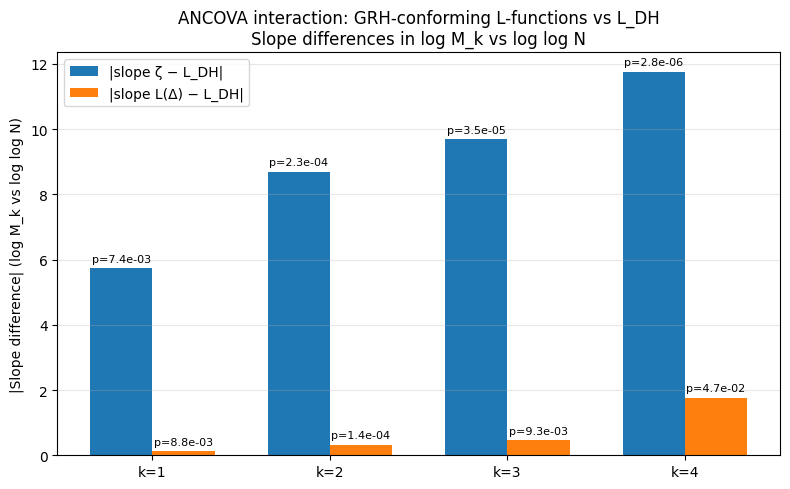

Saved figure.


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ks = comparison['omega_class_k'].values
x = np.arange(len(ks))
w = 0.35

bars1 = ax.bar(x - w/2, np.abs(comparison['diff (L_DH - ζ)']), w,
 label='|slope ζ − L_DH|', color='C0')
bars2 = ax.bar(x + w/2, np.abs(comparison['diff (L_DH - L(Δ))']), w,
 label='|slope L(Δ) − L_DH|', color='C1')

# annotate p-values
for i, k in enumerate(ks):
 p1 = comparison['p_inter (ζ vs L_DH)'].iloc[i]
 p2 = comparison['p_inter (L(Δ) vs L_DH)'].iloc[i]
 ax.text(i - w/2, np.abs(comparison['diff (L_DH - ζ)'].iloc[i]) + 0.2,
 f'p={p1:.1e}', ha='center', fontsize=8, rotation=0)
 ax.text(i + w/2, np.abs(comparison['diff (L_DH - L(Δ))'].iloc[i]) + 0.2,
 f'p={p2:.1e}', ha='center', fontsize=8, rotation=0)

ax.set_xticks(x)
ax.set_xticklabels([f'k={k}' for k in ks])
ax.set_ylabel('|Slope difference| (log M_k vs log log N)')
ax.set_title('ANCOVA interaction: GRH-conforming L-functions vs L_DH\n'
 'Slope differences in log M_k vs log log N')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ancova_zeta_vs_ldh_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure.')
